## Apply AIMS4PT Cpx to Merapi

This notebook applies the AIMS4PT clinopyroxene thermobarometry workflow to the Merapi case study, including data preparation, P-T calculation, equilibrium checks, and figure export.


## 1. Setup and Shared Model Pools

### Module and Data Imports

In [1]:
%matplotlib inline

from pathlib import Path
import sys

def _find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")

PROJECT_ROOT = _find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
CACHE_DIR = PAPER_DIR / ".cache"
IMAGES_DIR = PAPER_DIR / ".images"
DATA_DIR = PAPER_DIR / "data"
for _dir in (CACHE_DIR, IMAGES_DIR, DATA_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2
# %matplotlib widget
%matplotlib inline

import pandas as pd
import numpy as np
import sys
import os
import time
import importlib
import matplotlib.pyplot as plt
from aims4pt.model_tools.model_registry import  get_models_initial_pools, print_all_registered_thermobarometry, ALL_MODELS_MODULES
from aims4pt.toolkit_utils import get_file_path
for module in ALL_MODELS_MODULES:
    importlib.import_module(module)



calculate_shap = False # make sure this to False when not needed, as it takes time and memory

timestamp = time.strftime("%Y%m%d_%H%M")
timestamp = "add_pre-2006_028" 
CACHE_DIR = PAPER_DIR / ".cache"/ timestamp
CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:


#col names for unseen_experiments_df
cpx_names = ['SiO2_cpx', 'TiO2_cpx', 'Al2O3_cpx',
        'Cr2O3_cpx', 'FeO_cpx', 'MnO_cpx', 'MgO_cpx', 'NiO_cpx',
       'CaO_cpx', 'Na2O_cpx', 'K2O_cpx', 'P2O5_cpx']
liq_names = ['SiO2_liq', 'TiO2_liq', 'Al2O3_liq',
        'FeO_liq', 'MnO_liq', 'MgO_liq', 
       'CaO_liq', 'Na2O_liq', 'K2O_liq', 'P2O5_liq']
P_col = 'P (kbar)'
T_col = 'T (C)'


### Initial Thermobarometry Model Pools

In [3]:
P_model_pool = get_models_initial_pools("P", "both" , False) # get all P models including cpx_only and cpx_liq
P_model_names = list(model.model_name for model in P_model_pool)
T_model_pool = get_models_initial_pools("T", "both" , False) # get all T models including cpx_only and cpx_liq
T_model_names = list(model.model_name for model in T_model_pool)


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[skipped] Error initializing model <class 'aims4pt.model_tools.Neave_Putirka_17.Neave_Putirka_17'> with T: Pu08_eq33_T, P: eq1_P - Neave_Putirka_17 only supports pressure (P) calculations, not temperature (T) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

In [4]:
P_model_dict = {model.model_name: model for model in P_model_pool}
T_model_dict = {model.model_name: model for model in T_model_pool}

In [5]:
unseen_experiments_df_path = os.path.join(DATA_DIR, "independent_data_final.xlsx")
unseen_experiments_df = pd.read_excel(unseen_experiments_df_path)
cpx_unseen = unseen_experiments_df[cpx_names].copy()
liq_unseen = unseen_experiments_df[liq_names].copy()
meta_unseen = unseen_experiments_df[[P_col, T_col]].copy()

testing_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "testing"].index.tolist()
training_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "training"].index.tolist()


## 2. Loading and Preparing Merapi Data

In [6]:
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry
cpx_raw = pd.read_excel(os.path.join(DATA_DIR, "merapi_cpx.xlsx"))
liq_raw = pd.read_excel(os.path.join(DATA_DIR, "merapi_liq.xlsx"))
cpx_raw.columns = cpx_raw.columns.str.strip()
liq_raw.columns = liq_raw.columns.str.strip()
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
cpx_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO',
       'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO']
# Set water content (following Scruggs and Putirka, 2018)
# Liq_Comp['H2O_Liq']=Liq_Comp['SiO2_Liq']*0.06995+0.383
cpx_raw.keys()

Index(['Sample_id', 'Crystal_id', 'Crystal#', 'Eruption', 'Source', 'Rim/core',
       'SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'Cr2O3', 'NiO', 'F', 'Cl', 'TOTAL', '(Ca+Fe+Mg)/Si'],
      dtype='object')

In [7]:
cpx_06_input = cpx_raw[cpx_raw["Eruption"]==2006].reset_index(drop=True)
cpx_06_input


,Sample_id,Crystal_id,Crystal#,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,...,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si
0,2006px2 Line 001,2006px2,1,2006,"Costa et al., 2013",rim,50.742922,0.675655,3.419136,9.256879,...,14.746829,20.014550,0.427517,0.030893,NaN,NaN,0.083710,0.009965,100.036872,1.008423
1,2006px2 Line 002,2006px2,1,2006,"Costa et al., 2013",rim,49.958897,0.932331,4.417043,8.972431,...,13.695238,21.117794,0.411028,0.023058,NaN,NaN,0.012030,0.006015,100.006015,1.011768
2,2006px2 Line 003,2006px2,1,2006,"Costa et al., 2013",rim,49.069929,1.013068,5.125703,9.046187,...,13.039104,21.861953,0.396374,0.022133,NaN,NaN,0.022133,0.000000,100.009054,1.027670
3,2006px2 Line 004,2006px2,1,2006,"Costa et al., 2013",rim,48.042978,1.000727,6.222483,9.638688,...,12.317728,22.040231,0.383730,0.013128,NaN,NaN,0.008079,0.006059,100.004039,1.041543
4,2006px2 Line 005,2006px2,1,2006,"Costa et al., 2013",rim,49.064653,0.825188,5.260575,9.389521,...,12.899575,21.785371,0.392565,0.015022,NaN,NaN,0.000000,0.004006,100.001001,1.027721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Un 159 2006pair-clB-cpx-rim-W,2006pair-clB-cpx-RIM,22,2006,LI thesis,rim,51.637700,0.359146,1.598750,8.708690,...,15.158300,20.371000,0.390285,NaN,0.007531,0.010138,NaN,NaN,98.938200,1.001345
166,Un 160 2006pair-clB-cpx-CORE1,2006pair-clB-cpx-CORE,23,2006,LI thesis,core,51.437700,0.409381,1.926880,8.708280,...,15.110400,20.188000,0.356576,NaN,0.000000,0.020000,NaN,NaN,98.765400,1.000032
167,Un 161 2006pair-clB-cpx-CORE2,2006pair-clB-cpx-CORE,23,2006,LI thesis,core,51.680400,0.338079,1.557080,9.108510,...,14.964400,20.155600,0.369271,NaN,0.000000,0.000000,NaN,NaN,98.885900,0.996929
168,Un 163 2006pair-clB-cpx-99E,2006pair-clB-cpx-99,24,2006,LI thesis,NaN,51.210300,0.355892,1.568620,8.778750,...,14.858700,20.290900,0.365352,NaN,0.000000,0.002530,NaN,NaN,98.129900,1.000449


In [8]:
cpx_10_input = cpx_raw[cpx_raw["Eruption"]==2010].reset_index(drop=True)
cpx_10_input

,Sample_id,Crystal_id,Crystal#,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,...,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si
0,2010-cpx1 Line 002,2010-cpx1,5,2010,"Costa et al., 2013",rim,46.944338,1.620366,7.250910,10.177828,...,12.059705,21.104987,0.414395,0.074430,NaN,NaN,0.000000,0.006035,100.001006,1.045983
1,2010-cpx1 Line 003,2010-cpx1,5,2010,"Costa et al., 2013",rim,45.889246,1.790232,8.059587,10.460056,...,11.393122,21.696318,0.392657,0.048576,NaN,NaN,0.000000,0.000000,100.000000,1.067328
2,2010-cpx1 Line 004,2010-cpx1,5,2010,"Costa et al., 2013",rim,46.054772,1.771846,8.817550,10.425731,...,10.557882,21.597609,0.461513,0.026430,NaN,NaN,0.009149,0.000000,100.004066,1.033536
3,2010-cpx1 Line 005,2010-cpx1,5,2010,"Costa et al., 2013",rim,45.145040,1.826159,8.919170,10.696810,...,10.854754,21.809642,0.367503,0.029937,NaN,NaN,0.043357,0.002065,100.018582,1.074221
4,2010-cpx1 Line 006,2010-cpx1,5,2010,"Costa et al., 2013",rim,45.275865,1.719797,8.928589,10.595812,...,10.994166,21.870040,0.371056,0.034376,NaN,NaN,0.004044,0.006066,100.003033,1.075271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,Un 298 2010-CpxSkull-c1,2010-CpxSkull,44,2010,LI thesis,core,51.953300,0.382202,1.668580,8.934350,...,15.338800,20.047700,0.352465,NaN,0.000653,0.011991,NaN,NaN,99.457500,0.997407
301,Un 299 2010-CpxSkull-c2,2010-CpxSkull,44,2010,LI thesis,core,51.316300,0.375957,1.514440,8.941050,...,15.304600,20.101100,0.364818,NaN,0.000000,0.000000,NaN,NaN,98.661900,1.010019
302,Un 300 2010-CpxSkull-Rim2,2010-CpxSkull,44,2010,LI thesis,rim,47.082500,1.297910,6.205480,9.609230,...,12.300700,21.885100,0.361091,NaN,0.000000,0.003883,NaN,NaN,99.068800,1.058198
303,Un 301 2010-CpxSkull-Rim3,2010-CpxSkull,44,2010,LI thesis,rim,46.047900,1.521490,7.018780,9.964770,...,11.698400,21.992200,0.357622,NaN,0.006623,0.005107,NaN,NaN,98.910900,1.071423


## 3. Cpx-Liquid Pairing

### Pairing Setup

In [9]:
liq_cols = ['SiO2', 'TiO2',
       'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']


In [10]:
liq_2006 = liq_raw[(liq_raw["Eruption"]==2006) | (liq_raw["Eruption"]=="pre-2006")].reset_index(drop=True)
liq_2010 = liq_raw[(liq_raw["Eruption"]==2010) | (liq_raw["Eruption"]=="pre-2006")].reset_index(drop=True)

In [11]:
from aims4pt.data_tools.eq_pairing import PairingResult, pair_mineral_liquid_by_kd


def pair_mineral_liquid_by_kd_excel_cache(cache_path, **pairing_kwargs):
    """Run Kd pairing once, then reuse the Excel cache on later notebook runs."""
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        print(f"Reading cached pairing result: {cache_path}")
        pairs = pd.read_excel(cache_path, sheet_name="pairs")
        mask_df = pd.read_excel(cache_path, sheet_name="pairs_pass_mask")
        cleaned_minerals = pd.read_excel(cache_path, sheet_name="cleaned_minerals")
        cleaned_liquids = pd.read_excel(cache_path, sheet_name="cleaned_liquids")
        mask_values = mask_df["pairs_pass_mask"]
        if mask_values.dtype == object:
            pairs_pass_mask = mask_values.astype(str).str.lower().isin(["true", "1", "yes"])
        else:
            pairs_pass_mask = mask_values.astype(bool)
        pairs_pass_mask.index = pairs.index
        return PairingResult(
            pairs=pairs,
            pairs_pass_mask=pairs_pass_mask,
            cleaned_minerals=cleaned_minerals,
            cleaned_liquids=cleaned_liquids,
        )

    result = pair_mineral_liquid_by_kd(**pairing_kwargs)
    with pd.ExcelWriter(cache_path) as writer:
        result.pairs.to_excel(writer, sheet_name="pairs", index=False)
        result.pairs_pass_mask.rename("pairs_pass_mask").to_frame().to_excel(
            writer, sheet_name="pairs_pass_mask", index=False
        )
        result.cleaned_minerals.to_excel(writer, sheet_name="cleaned_minerals", index=False)
        result.cleaned_liquids.to_excel(writer, sheet_name="cleaned_liquids", index=False)
    print(f"Wrote pairing cache: {cache_path}")
    return result


res_06 = pair_mineral_liquid_by_kd_excel_cache(
    CACHE_DIR / "merapi_2006_pairing_kd028_err1e-4_n20000_endmembers.xlsx",
    X_mine=cpx_06_input,
    X_liq=liq_2006[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=20000,
    endmember1=liq_2006[liq_2006['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2006[liq_2006['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,
    kd=0.28,
    error=1e-4,
)

paired_cpx_06, paired_liq_06 = res_06.cleaned_minerals, res_06.cleaned_liquids
paired_cpx_06_pass = paired_cpx_06[res_06.pairs_pass_mask].reset_index(drop=True)
paired_liq_06_pass = paired_liq_06[res_06.pairs_pass_mask].reset_index(drop=True)


len(paired_cpx_06_pass)

Reading cached pairing result: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\merapi_2006_pairing_kd028_err1e-4_n20000_endmembers.xlsx


42

In [12]:
res_06.pairs[~res_06.pairs_pass_mask]

,mine__Sample_id,mine__Crystal_id,mine__Crystal#,mine__Eruption,mine__Source,mine__Rim/core,mine__SiO2,mine__TiO2,mine__Al2O3,mine__FeO,...,liq__liq__mix_f,liq__liq__endmember1_idx,liq__liq__endmember2_idx,mine__pair_mine_id,liq__pair_liq_id,mine__pair_row_idx,liq__pair_row_idx,kd_value,kd_error,if_pass_test
5,2006px2 Line 006,2006px2,1,2006,"Costa et al., 2013",core,52.509229,0.426020,1.711065,8.834680,...,NaN,NaN,NaN,5,11,5,11,0.257209,0.022791,False
6,2006px2 Line 007,2006px2,1,2006,"Costa et al., 2013",core,52.414244,0.345036,1.847903,8.610804,...,NaN,NaN,NaN,6,11,6,11,0.252627,0.027373,False
7,2006px2 Line 008,2006px2,1,2006,"Costa et al., 2013",core,52.173479,0.388014,2.420851,8.803639,...,NaN,NaN,NaN,7,11,7,11,0.266375,0.013625,False
8,2006px2 Line 009,2006px2,1,2006,"Costa et al., 2013",core,52.615515,0.307234,1.800087,8.602540,...,NaN,NaN,NaN,8,11,8,11,0.253435,0.026565,False
9,2006px2 Line 010,2006px2,1,2006,"Costa et al., 2013",core,52.962436,0.313364,1.768051,8.527892,...,NaN,NaN,NaN,9,11,9,11,0.252182,0.027818,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Un 159 2006pair-clB-cpx-rim-W,2006pair-clB-cpx-RIM,22,2006,LI thesis,rim,51.637700,0.359146,1.598750,8.708690,...,NaN,NaN,NaN,165,11,165,11,0.258044,0.021956,False
166,Un 160 2006pair-clB-cpx-CORE1,2006pair-clB-cpx-CORE,23,2006,LI thesis,core,51.437700,0.409381,1.926880,8.708280,...,NaN,NaN,NaN,166,11,166,11,0.258850,0.021150,False
167,Un 161 2006pair-clB-cpx-CORE2,2006pair-clB-cpx-CORE,23,2006,LI thesis,core,51.680400,0.338079,1.557080,9.108510,...,NaN,NaN,NaN,167,11,167,11,0.273388,0.006612,False
168,Un 163 2006pair-clB-cpx-99E,2006pair-clB-cpx-99,24,2006,LI thesis,NaN,51.210300,0.355892,1.568620,8.778750,...,NaN,NaN,NaN,168,11,168,11,0.265365,0.014635,False


In [13]:
# kd range 
res_06.pairs["kd_value"].describe()

count    170.000000
mean       0.262820
std        0.014777
min        0.219426
25%        0.252270
50%        0.263529
75%        0.279461
max        0.280026
Name: kd_value, dtype: float64

In [14]:
res_10 = pair_mineral_liquid_by_kd_excel_cache(
    CACHE_DIR / "merapi_2010_pairing_kd028_err1e-4_n20000_endmembers.xlsx",
    X_mine=cpx_10_input,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=20000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,
    kd=0.28,
    error=1e-4,
)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)



len(paired_cpx_10_pass)


Reading cached pairing result: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\merapi_2010_pairing_kd028_err1e-4_n20000_endmembers.xlsx


106

In [15]:
res_06.pairs[res_06.pairs_pass_mask]["kd_value"]

0      0.279997
1      0.279987
2      0.280016
3      0.280000
4      0.280000
10     0.279967
11     0.280000
35     0.279968
36     0.280001
37     0.280016
38     0.280000
39     0.280004
40     0.279999
41     0.280000
42     0.280002
43     0.280008
44     0.279979
58     0.280003
59     0.279997
74     0.280002
76     0.280026
77     0.280004
80     0.280004
81     0.279983
82     0.279997
83     0.280003
85     0.280013
86     0.279976
87     0.280004
88     0.279997
89     0.279972
90     0.279997
91     0.279991
108    0.279995
109    0.279994
110    0.279996
111    0.280009
112    0.279986
116    0.279987
135    0.279997
139    0.280007
140    0.279992
Name: kd_value, dtype: float64

## 4. Cpx-Liquid Thermobarometry

### Cpx-Liquid Setup

In [16]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_liq_pool = [model for model in P_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_P_06 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_P_10 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"

from aims4pt.reporting.excel import report_excel
report_excel(
    workflow_obj=workflow_cpx_liq_P_06,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_P_10,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2006_P_workflow_cpx_liq_P_add_pre-2006_028.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2010_P_workflow_cpx_liq_P_add_pre-2006_028.pkl


In [17]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_liq_pool = [model for model in T_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_T_06 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_T_10 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_liq_T_06,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_T_10,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2006_T_workflow_cpx_liq_T_add_pre-2006_028.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2010_T_workflow_cpx_liq_T_add_pre-2006_028.pkl


## 5. Cpx-Only Thermobarometry

### Cpx-Only Setup

In [18]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_only_pool = [model for model in P_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_P_06 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_P_10 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_P_06,
    model_list =P_cpx_only_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_P_10,
    model_list =P_cpx_only_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2006_P_workflow_cpx_only_P_add_pre-2006_028.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2010_P_workflow_cpx_only_P_add_pre-2006_028.pkl


In [19]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_only_pool = [model for model in T_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_T_06 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_T_10 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_T_06,
    model_list =T_cpx_only_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_T_10,
    model_list =T_cpx_only_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2006_T_workflow_cpx_only_T_add_pre-2006_028.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\marapi_2010_T_workflow_cpx_only_T_add_pre-2006_028.pkl


## 6. Liquid Thermobarometry

### Data Preparation

In [20]:
glass_mineral  = {
    'ol': 0, #
    'opx': 1,
    'cpx': 1,
    'plag': 1,
    'amph': 1,
    'ox': 1,
    'bt': 0, #
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

whole_rock_mineral_2  = {
    'ol': 1,
    'opx': 1,
    'cpx': 1,
    'plag': 0,
    'amph': 0,
    'ox': 0,
    'bt': 0,
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

glass_mineral_df = pd.DataFrame([glass_mineral])
whole_rock_mineral_df_2 = pd.DataFrame([whole_rock_mineral_2])  


# liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
# liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)
liq_2006_glass = liq_2006[liq_2006["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2006_bulk = liq_2006[liq_2006["glass/bulk"]=="bulk"].reset_index(drop=True)
liq_2010_glass = liq_2010[liq_2010["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2010_bulk = liq_2010[liq_2010["glass/bulk"]=="bulk"].reset_index(drop=True)



In [21]:
from aims4pt.model_tools.other_models.WandB24_melt import WandB24_melt


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


### Glass Calculations

In [22]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",4) # 4 is the maximum
P_06_glass = P_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))

P_06_glass

0    2.571405
1    2.617135
2    2.597763
3    2.613756
4    2.385761
5    2.834220
6    2.701609
Name: P_kbar, dtype: float64

In [23]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_glass = P_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))

P_10_glass

0    3.624881
1    4.176075
2    3.883335
3    4.475628
4    3.583497
5    4.521359
6    4.835092
Name: P_kbar, dtype: float64

In [24]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 4)
T_06_glass = T_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))
T_06_glass

0    896.734320
1    895.690263
2    900.823777
3    887.202860
4    912.499878
5    890.807947
6    933.464901
Name: T_C, dtype: float64

In [25]:
T_10_glass = T_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))
T_10_glass

0    908.453739
1    944.435455
2    905.130439
3    939.026039
4    940.386646
5    928.743372
6    964.146544
Name: T_C, dtype: float64

### Whole-Rock Calculations

In [26]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",3)
P_06_bulk = P_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))

P_06_bulk

0    6.282600
1    6.306187
2    6.437876
3    8.125607
4    8.095017
5    9.078031
6    8.298289
Name: P_kbar, dtype: float64

In [27]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_bulk = P_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))

P_10_bulk

0    6.530688
1    6.752381
2    6.587118
3    6.815809
4    6.808471
5    6.788134
6    8.125607
7    8.095017
8    9.078031
9    8.298289
Name: P_kbar, dtype: float64

In [28]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 3)
T_06_bulk = T_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))
T_06_bulk

0    1055.818273
1    1053.651935
2    1063.067838
3    1098.733966
4    1103.323555
5    1093.859579
6    1091.772572
Name: T_C, dtype: float64

In [29]:
T_10_bulk = T_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))
T_10_bulk

0    1061.506121
1    1066.706402
2    1065.909294
3    1077.922585
4    1073.216512
5    1073.105220
6    1098.733966
7    1103.323555
8    1093.859579
9    1091.772572
Name: T_C, dtype: float64

## 7. Merapi compositions comparison with the independent dataset



In [30]:
from paper.scripts.figure_helpers import save_figure_pdf_png
from paper.scripts.merapi_helpers import plot_merapi_composition_comparison

import matplotlib.pyplot as plt


fig7, axes = plot_merapi_composition_comparison(
    unseen_experiments_df,
    paired_cpx_06_pass,
    paired_liq_06_pass,
    paired_cpx_10_pass,
    paired_liq_10_pass,
    liq_2006,
    liq_2010,
    mixing_path_display="curves",
)
save_figure_pdf_png(fig7, IMAGES_DIR, "Fig_S15_Merapi_compositions_comparison", dpi=300, bbox_inches="tight")


c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\scripts\merapi_helpers.py:771: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_S15_Merapi_compositions_comparison.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_S15_Merapi_compositions_comparison.png'))

fig_7_Merapi_compositions_comparison
mixing path apha 调高一点， equilibrium liquid 颜色再调深， alpha =1 。

现在 的 1sigma 范围， 2sigma 范围改成 68.3%，95.4% 范围，标也只标 百分比


## 8. Merapi Plots and Comparison Figures

### Plotting Setup

In [31]:


df = pd.DataFrame({
    "min km": [1.5, 1.5,2, 0 , 10, 25],
    "max km": [2.5, 2.5,3, 4, 15, 45],
    "uncertainty": [1, 0.5, np.nan, 5, 5, 5],
})

from aims4pt.data_tools.crust import kbar_to_km_multilayer, km_to_kbar_multilayer
densities_kg_m3=[2242, 2900]
layer_boundaries_km=[10]

min_kbar = km_to_kbar_multilayer(df["min km"], densities_kg_m3, layer_boundaries_km)
max_kbar = km_to_kbar_multilayer(df["max km"], densities_kg_m3, layer_boundaries_km)
df["min kbar"] = min_kbar
df["max kbar"] = max_kbar
df

,min km,max km,uncertainty,min kbar,max kbar
0,1.5,2.5,1.0,0.329910,0.549851
1,1.5,2.5,0.5,0.329910,0.549851
2,2.0,3.0,NaN,0.439880,0.659821
3,0.0,4.0,5.0,0.000000,0.879761
4,10.0,15.0,5.0,2.199402,3.621852
5,25.0,45.0,5.0,6.466752,12.156552


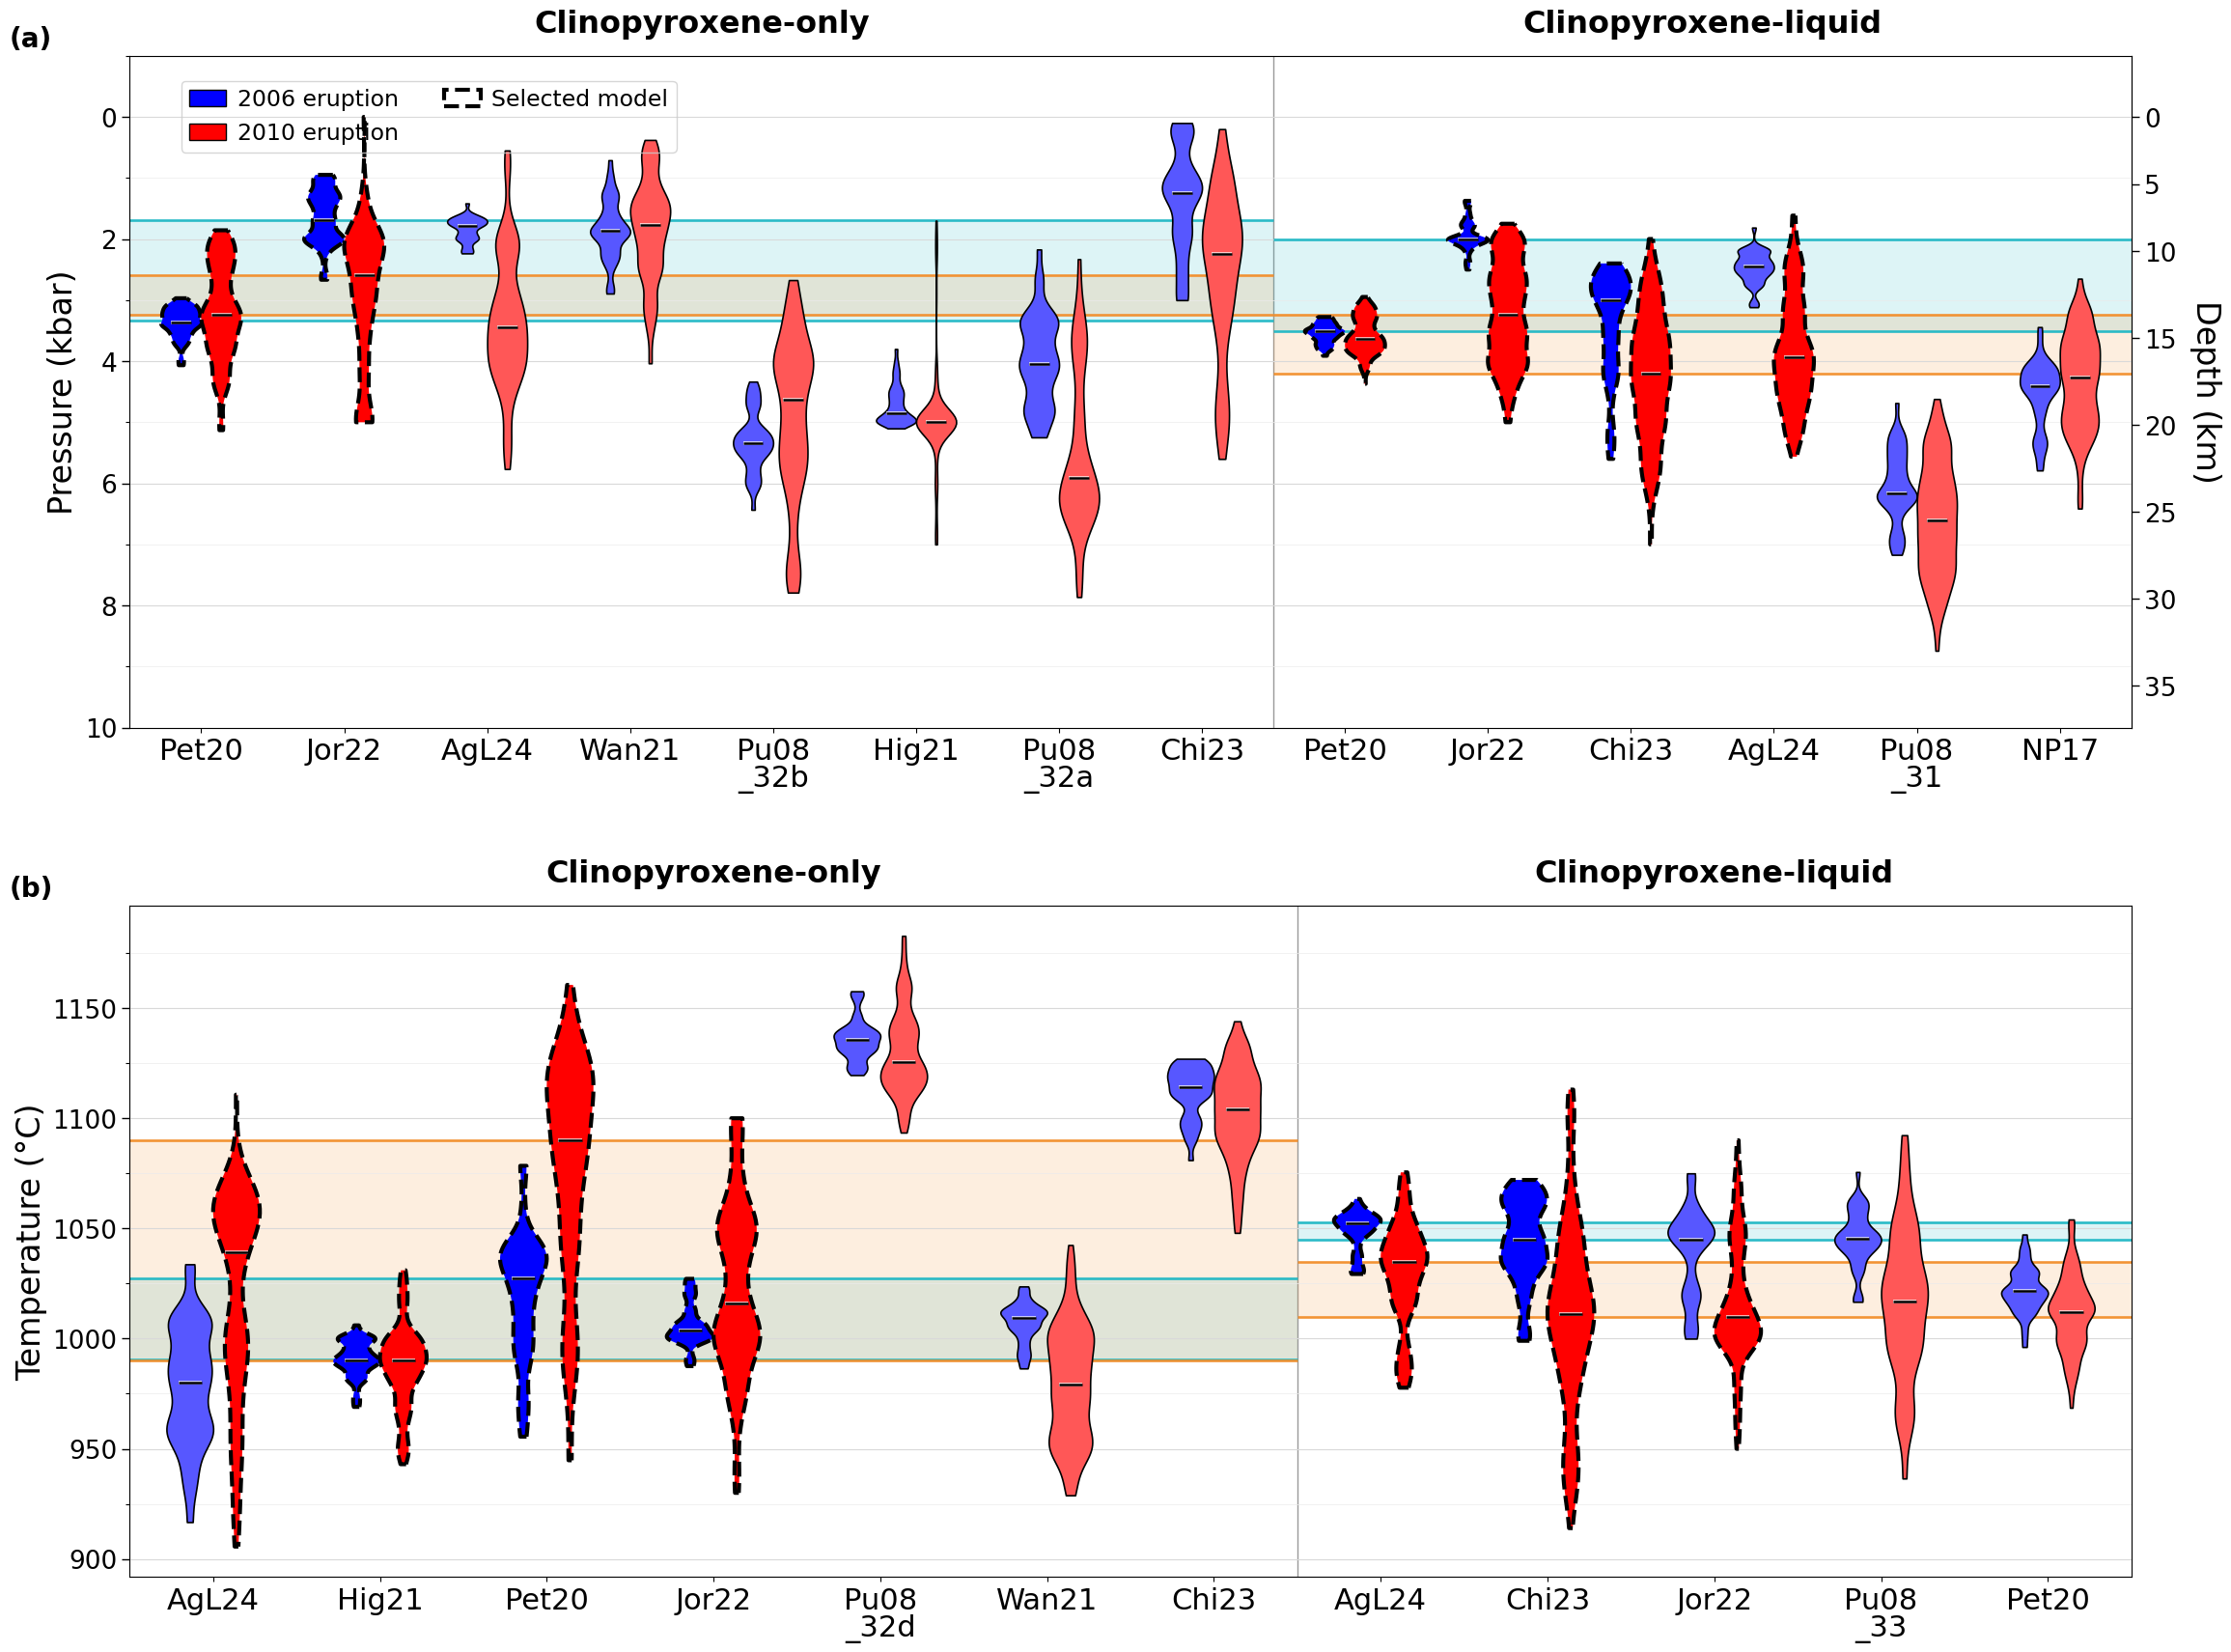

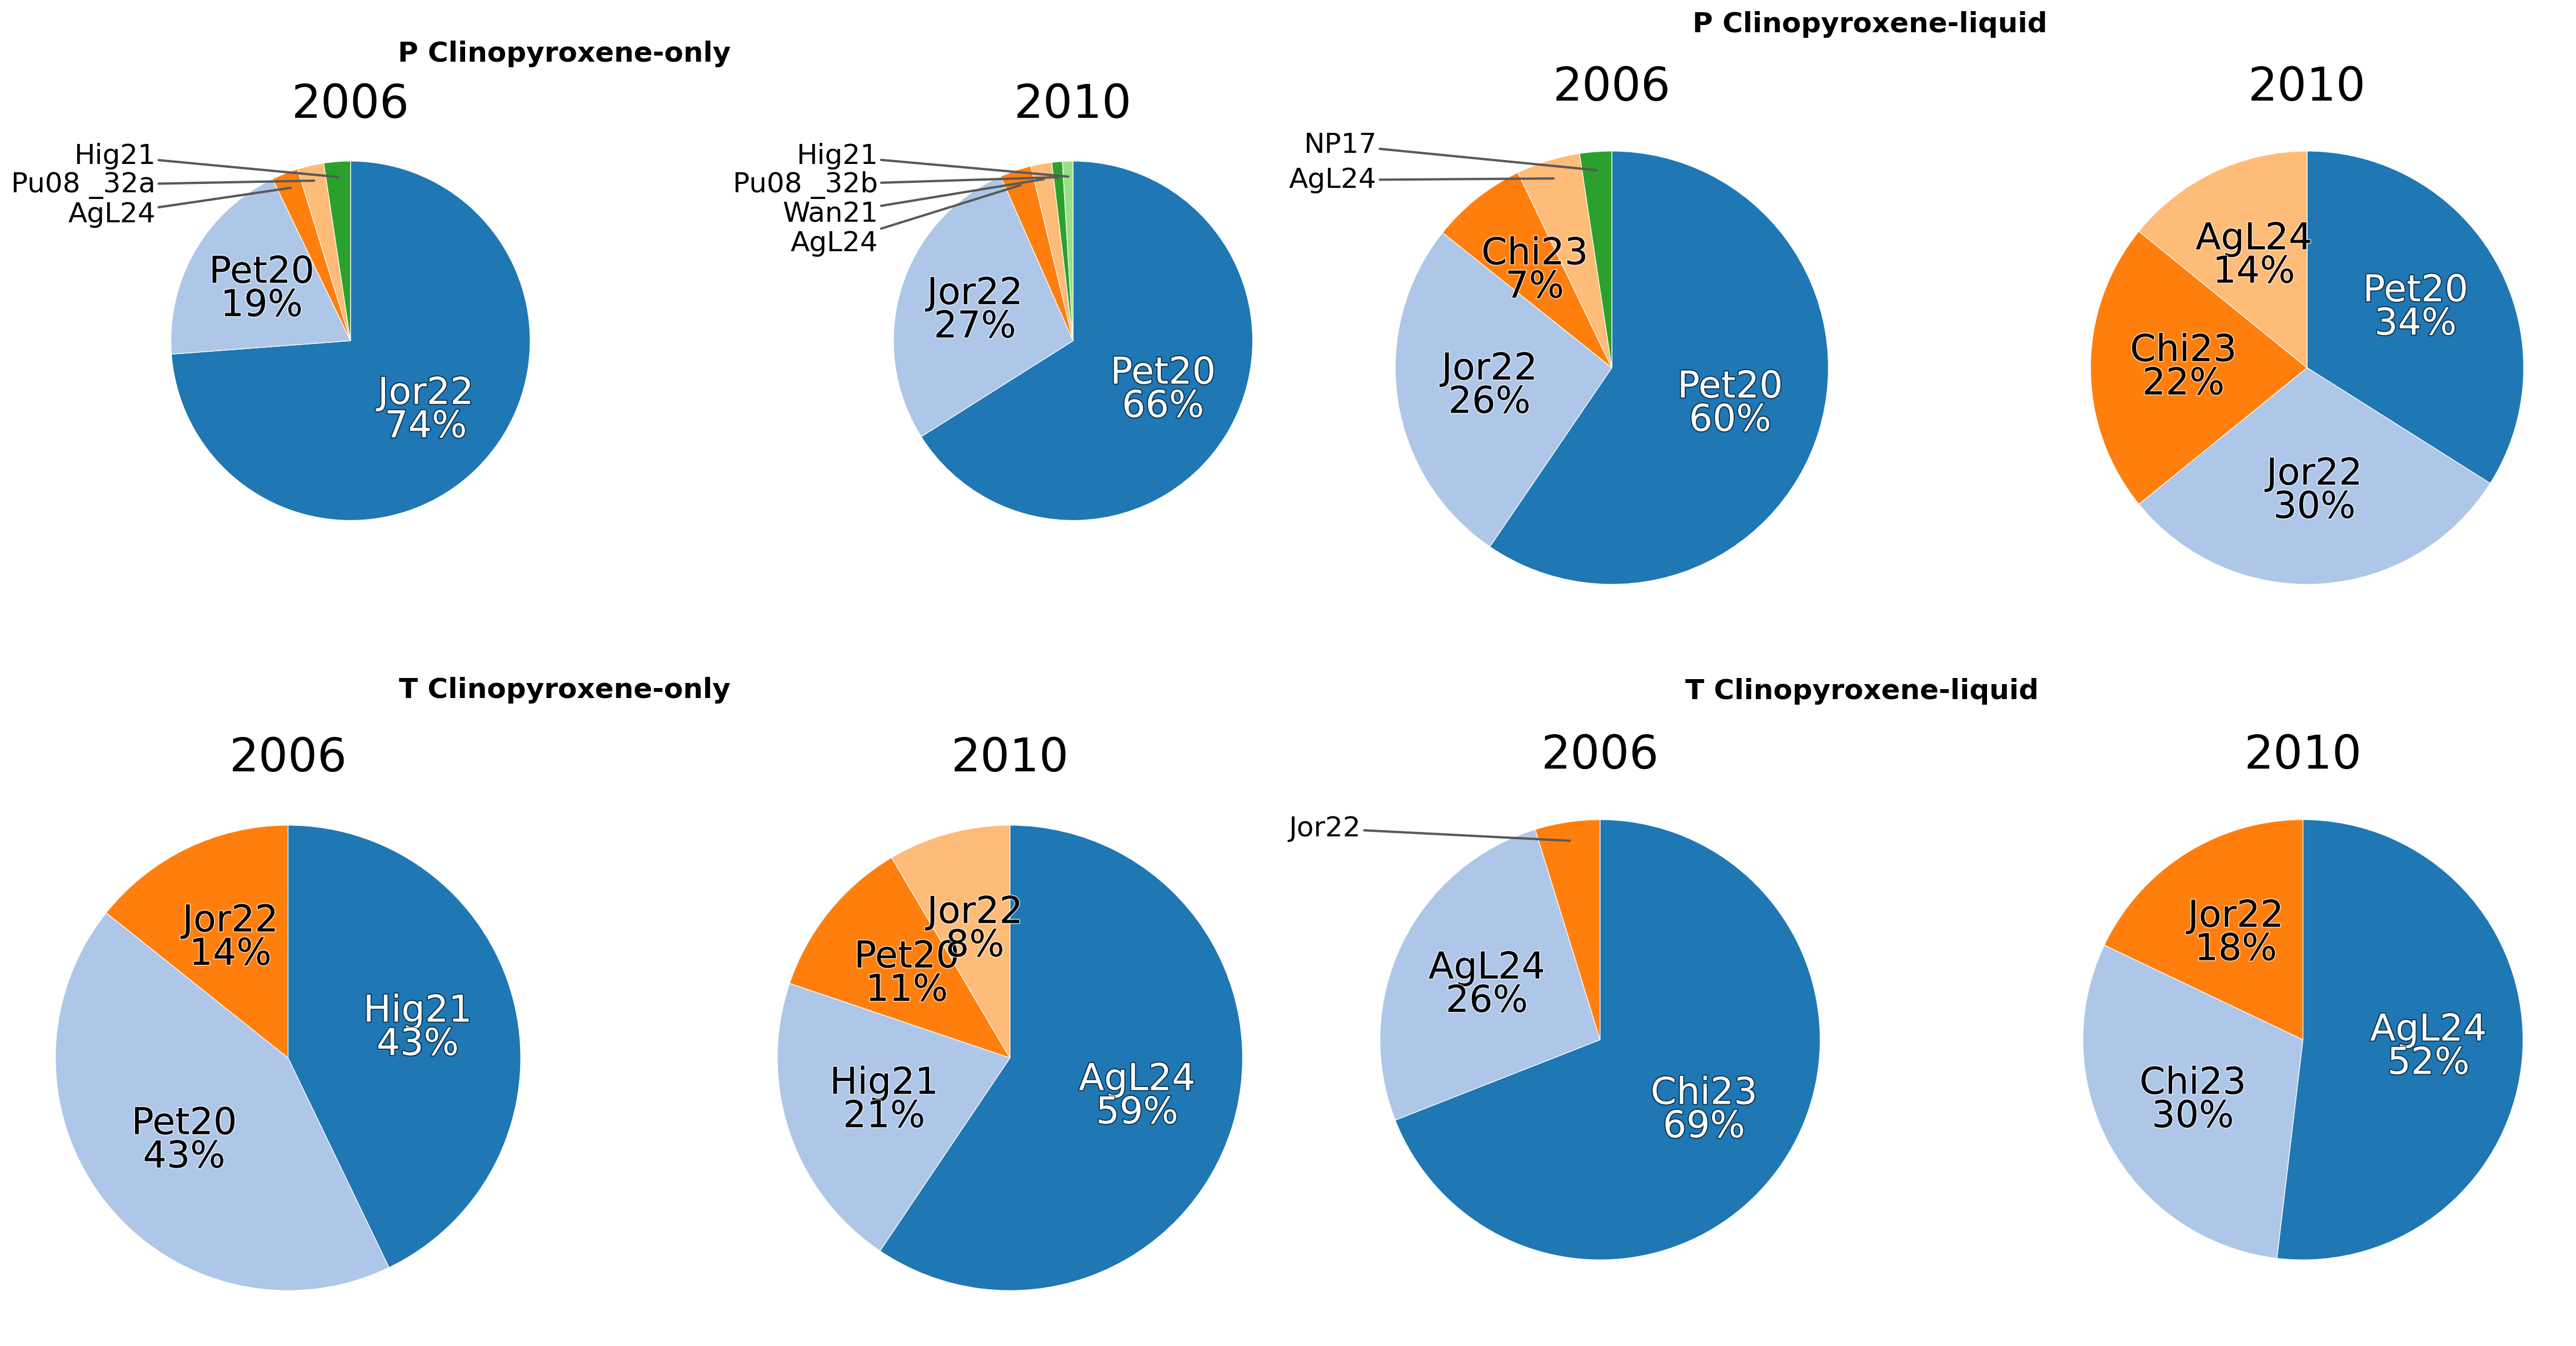

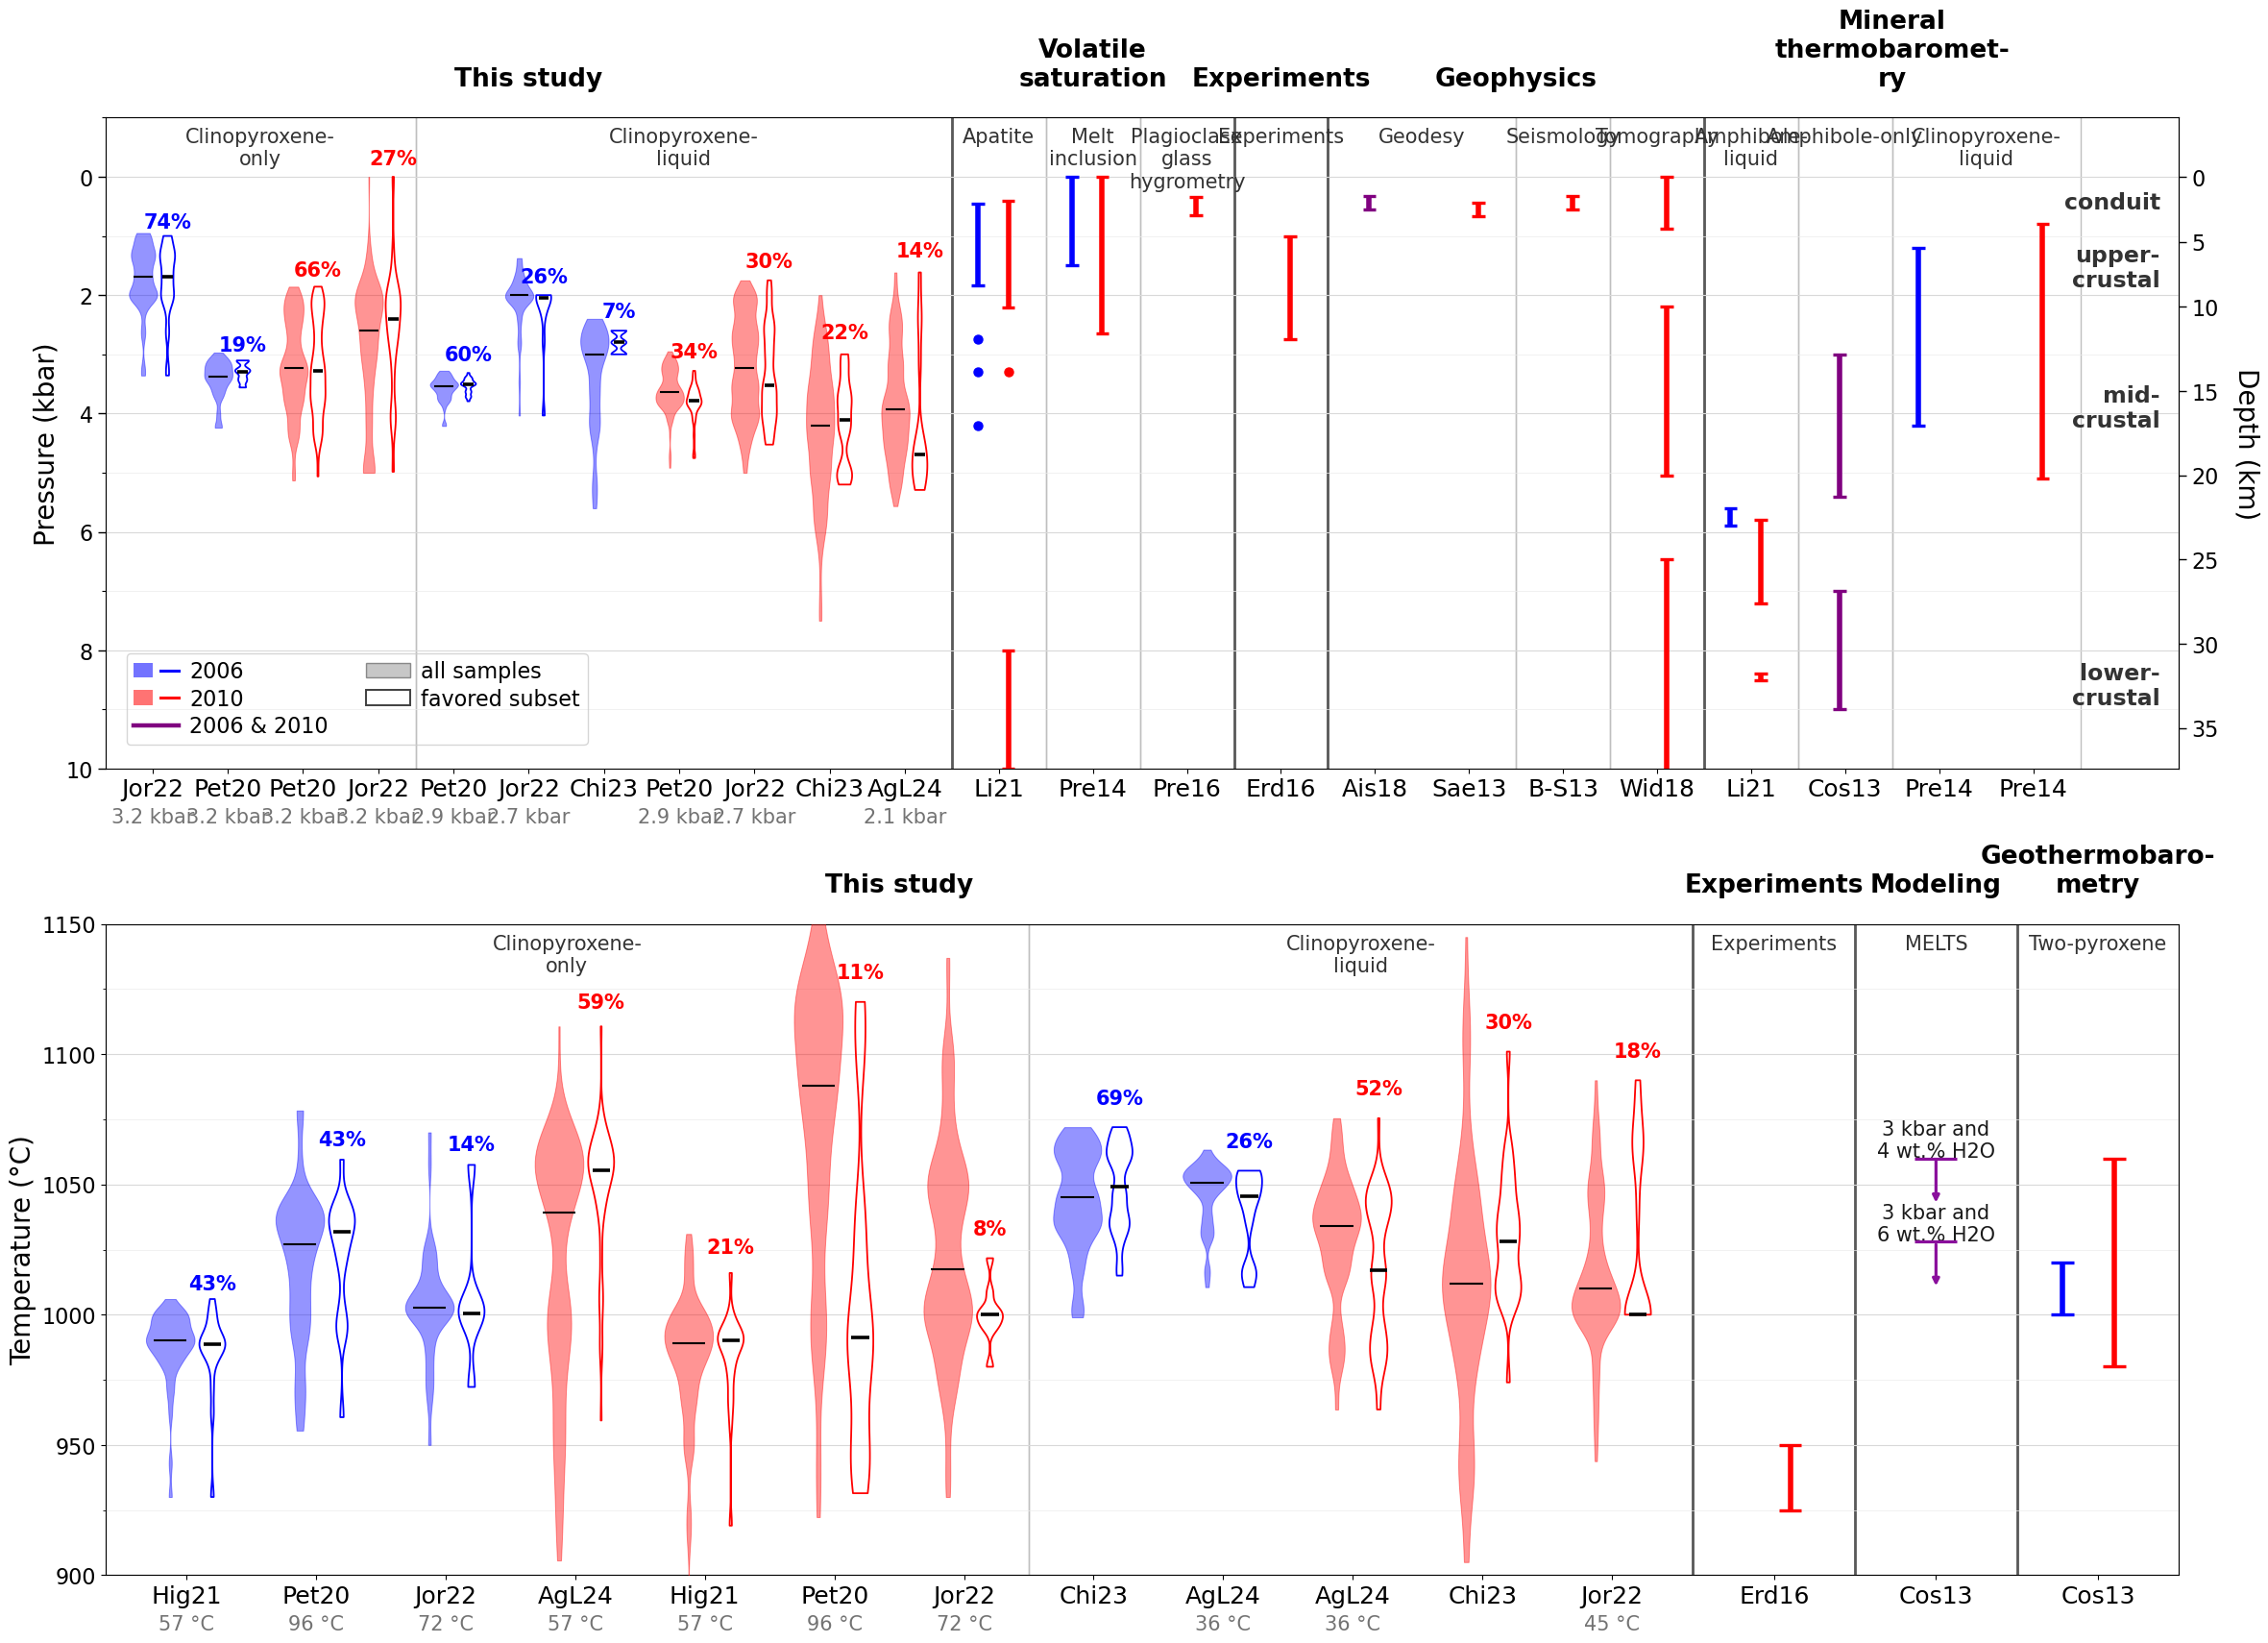

(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_8_Merapi_P_T.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_8_Merapi_P_T.png'))

In [32]:

from aims4pt.model_tools.ModelManager import ModelManager
from paper.scripts.merapi_helpers import (
    ThermobarometryWorkflowBundle,
    _build_ranked_thermobarometry_state,
    export_ranked_thermobarometry_model_summary,
    plot_ranked_thermobarometry_literature_comparison,
    plot_ranked_thermobarometry_summary,
)
from paper.scripts.figure_helpers import save_figure_pdf_png

T_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_T.xlsx")
P_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_P.xlsx")

P_lit_raw = pd.read_excel(P_LIT_PATH)
T_lit_raw = pd.read_excel(T_LIT_PATH)
P_lit_plot = P_lit_raw[P_lit_raw["plot"] == True].reset_index(drop=True)
T_lit_plot = T_lit_raw[T_lit_raw["plot"] == True].reset_index(drop=True)


def _fig9_v2_literature_rows(df):
    """Return rows shown in Fig. 9 v2 using the Excel plot flag only."""
    plot_mask = df["plot"].fillna(False).astype(bool) if "plot" in df.columns else pd.Series(False, index=df.index)
    return df.loc[plot_mask].reset_index(drop=True)


P_lit_fig9_v2 = _fig9_v2_literature_rows(P_lit_raw)
T_lit_fig9_v2 = _fig9_v2_literature_rows(T_lit_raw)

densities_kg_m3 = [2242, 2900]
layer_boundaries_km = [10]


def _get_model_name(pool, T_P, cpx_only, aliases):
    """Return the model_name for the first matching alias."""
    for alias in aliases:
        model = ModelManager.get_model(
            pool,
            model_name=alias,
            T_P=T_P,
            cpx_only=cpx_only,
            exact=False,
            raise_if_empty=False,
        )
        if model is not None:
            return model.model_name
    raise ValueError(f"No model matched aliases: {aliases}")


def _get_model_names(pool, T_P, cpx_only, alias_groups):
    return [_get_model_name(pool, T_P, cpx_only, aliases) for aliases in alias_groups]


T_cols_liq = _get_model_names(
    T_model_pool,
    "T",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)
P_cols_liq = _get_model_names(
    P_model_pool,
    "P",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Neave & Putirka"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)

P_cols_only = _get_model_names(
    P_model_pool,
    "P",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Putirka, 2008 eq32d_T; eq32b_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)
T_cols_only = _get_model_names(
    T_model_pool,
    "T",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)

cpx_only = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_only_P_06,
    pressure_2010=workflow_cpx_only_P_10,
    temperature_2006=workflow_cpx_only_T_06,
    temperature_2010=workflow_cpx_only_T_10,
)

cpx_liq = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_liq_P_06,
    pressure_2010=workflow_cpx_liq_P_10,
    temperature_2006=workflow_cpx_liq_T_06,
    temperature_2010=workflow_cpx_liq_T_10,
)

liquid_results = {
    "P": {
        "2006": {"glass": P_06_glass, "bulk": P_06_bulk},
        "2010": {"glass": P_10_glass, "bulk": P_10_bulk},
    },
    "T": {
        "2006": {"glass": T_06_glass, "bulk": T_06_bulk},
        "2010": {"glass": T_10_glass, "bulk": T_10_bulk},
    },
}

fig8_order_state = _build_ranked_thermobarometry_state(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=None,
)


def _sort_model_columns_by_2010_selection_proportion(columns, rank_pcts):
    """Sort model columns by descending 2010 best-model selection proportion."""
    rank_pct_map = {model_name: float(pct) for model_name, pct in rank_pcts}
    return [
        model_name
        for _, model_name in sorted(
            enumerate(columns),
            key=lambda item: (-rank_pct_map.get(item[1], 0.0), item[0]),
        )
    ]


P_cols_only = _sort_model_columns_by_2010_selection_proportion(
    P_cols_only,
    fig8_order_state["P"]["ranks"]["2010"]["cpx_only"],
)
P_cols_liq = _sort_model_columns_by_2010_selection_proportion(
    P_cols_liq,
    fig8_order_state["P"]["ranks"]["2010"]["cpx_liq"],
)
T_cols_only = _sort_model_columns_by_2010_selection_proportion(
    T_cols_only,
    fig8_order_state["T"]["ranks"]["2010"]["cpx_only"],
)
T_cols_liq = _sort_model_columns_by_2010_selection_proportion(
    T_cols_liq,
    fig8_order_state["T"]["ranks"]["2010"]["cpx_liq"],
)

# 2010 reservoir depth ranges. These values are explicit for easy later editing.
MERAPI_2010_RESERVOIR_BANDS = [
    {
        "label": "conduit",
        "min_depth_km": 0,
        "max_depth_km": 4,
        "color": "#D7E9F7",
        "alpha": 0.26,
    },
    {
        "label": "upper-\ncrustal",
        "min_depth_km": 4,
        "max_depth_km": 10,
        "color": "#9EC5E8",
        "alpha": 0.25,
        "hatch": "///",
        "edgecolor": "#5F88B6",
        "linestyle": "--",
    },
    {
        "label": "mid-\ncrustal",
        "min_depth_km": 13,
        "max_depth_km": 19,
        "color": "#F3B4A7",
        "alpha": 0.24,
    },
    {
        "label": "lower-\ncrustal",
        "min_depth_km": 25,
        "max_depth_km": 40,
        "color": "#D96B6B",
        "alpha": 0.24,
    },
]

AIMS4PT_WORKFLOW_RMSE = {
    ("P", "cpx_only"): 1.52,
    ("P", "cpx_liq"): 1.67,
    ("T", "cpx_only"): 60,
    ("T", "cpx_liq"): 41,
}

figs = plot_ranked_thermobarometry_summary(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    model_selection_mode="above_threshold",
    selection_threshold=5.0,
    pressure_literature=P_lit_plot,
    temperature_literature=T_lit_plot,
    liquid_results=None,
    pressure_ylim=(-1, 10),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    this_study_figsize=(23.0, 17.0),
    this_study_subplot_hspace=0.08,
    literature_figsize=(23.5, 17.0),
    literature_this_study_x_spacing=0.8,
    show=True,
    use_model_abbreviations=True,
    literature_include_temperature=True,
    literature_panel_labels=(),
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
    this_study_tick_labelsize=19,
    this_study_model_tick_labelsize=22,
    split_literature_legend=True,
    literature_legend_bbox_to_anchor=(0.47, 0.09),
    literature_model_tick_labelsize=18,
    literature_reservoir_label_x_offset=1.35,
    literature_reservoir_label_right_margin=0.20,
    rank_pie_save_path=IMAGES_DIR / "fig_8_Merapi_model_rank_pies.png",
)
save_figure_pdf_png(figs["this_study"][0], IMAGES_DIR, "Fig_8_Merapi_P_T")


In [ ]:

fig_s_merapi_pt, axes_s_merapi_pt = plot_ranked_thermobarometry_literature_comparison(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_literature=P_lit_plot.iloc[0:0],
    temperature_literature=T_lit_plot.iloc[0:0],
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=None,
    selection_threshold=5.0,
    model_selection_mode="above_threshold",
    pressure_ylim=(-0.8, 7.8),
    temperature_ylim=(880, 1180),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    figsize=(19.0, 17.0),
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
    panel_labels=(),
    split_literature_legend=True,
    literature_legend_bbox_to_anchor=(0.47, 0.09),
    literature_tick_labelsize=21,
    literature_model_tick_labelsize=23,
    literature_group_label_fontsize=23,
    literature_annotation_fontsize=19,
    literature_this_study_x_spacing=0.8,
    show_quartile_interval=False,
    literature_annotate_model_rmse=False,
    literature_workflow_rmse_by_kind_phase=AIMS4PT_WORKFLOW_RMSE,
    literature_workflow_rmse_errorbar_fontsize=17,
    literature_show_pressure_reservoir_labels=False,
    literature_show_last_type_boundary=False,
)
save_figure_pdf_png(fig_s_merapi_pt, IMAGES_DIR, "Fig_S16_Merapi_PT_estimates")


Wrote model summary Excel: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_pre-2006_028\merapi_fig8_9_model_summary.xlsx


In [34]:
from matplotlib.legend_handler import HandlerTuple
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import AutoMinorLocator, NullLocator

from paper.scripts.constants_illustration import get_model_abbreviation
from paper.scripts.merapi_helpers import (
    _add_category_and_type_bands,
    _add_pressure_reservoir_bands,
    _apply_pressure_depth_axes,
    _apply_threshold_xtick_rotation,
    _build_ranked_thermobarometry_state,
    _clean_str,
    _draw_literature_comparison_violin,
    _draw_melts_modeling_column,
    _group_literature_methods,
    _is_melts_modeling_method,
    _model_axis_label,
    _remove_boxplot_outliers,
    _selected_predictions_for_model,
    _selected_predictions_from_best_models,
    _wrap_label,
    _eruption_color,
    _eruption_slot_offset,
)

def _finite_array(values):
    """Return finite numeric values as a one-dimensional array."""
    arr = np.asarray(values, dtype=float).ravel()
    return arr[np.isfinite(arr)]


FIG9_FINAL_RESULT_SELECTION = {
    ("P", "cpx_only", "2006"): "Jor22",
    ("P", "cpx_only", "2010"): "Pet20",
    ("T", "cpx_only", "2006"): "Hig21",
    ("T", "cpx_only", "2010"): "overall",
    ("P", "cpx_liq", "2006"): "overall",
    ("P", "cpx_liq", "2010"): "Pet20",
    ("T", "cpx_liq", "2006"): "Chi23",
    ("T", "cpx_liq", "2010"): "AgL24",
}

AIMS4PT_WORKFLOW_RMSE = globals().get(
    "AIMS4PT_WORKFLOW_RMSE",
    {
        ("P", "cpx_only"): 1.52,
        ("P", "cpx_liq"): 1.67,
        ("T", "cpx_only"): 60,
        ("T", "cpx_liq"): 41,
    },
)


def _fig9_final_result_model_name(kind, phase_type, year, df_pred):
    """Return the configured Fig. 9 final-result model column name."""
    target_abbrev = FIG9_FINAL_RESULT_SELECTION[(kind, phase_type, year)]
    for model_name in df_pred.columns:
        if get_model_abbreviation(model_name, kind) == target_abbrev:
            return model_name
    raise KeyError(f"Missing Fig. 9 final-result model {target_abbrev} for {kind} {phase_type} {year}.")


def _build_fig9_threshold_columns(kind, state, *, min_pct=5.0, use_model_abbreviations=True):
    """Build only the configured final-result column for each calculation group."""
    kind_state = state[kind]
    columns = []
    for phase_type in ("cpx_only", "cpx_liq"):
        for year in ("2006", "2010"):
            df_pred = kind_state["results"][year][phase_type]
            best_models = kind_state["best_models"][year][phase_type]
            rank_pcts = kind_state["ranks"][year][phase_type]
            fill = "blue" if year == "2006" else "red"
            final_result = FIG9_FINAL_RESULT_SELECTION[(kind, phase_type, year)]

            overall_data = _remove_boxplot_outliers(
                _selected_predictions_from_best_models(df_pred, best_models)
            )
            overall_uncertainty = AIMS4PT_WORKFLOW_RMSE.get((kind, phase_type), np.nan)
            if final_result == "overall":
                columns.append(
                    {
                        "category": "This study",
                        "type": phase_type,
                        "eruption": year,
                        "model": "overall",
                        "label": "Ov.",
                        "data": overall_data,
                        "fill": fill,
                        "uncertainty": overall_uncertainty,
                        "is_overall": True,
                        "final_result": "Overall distribution",
                    }
                )
                continue

            recommended_model = _fig9_final_result_model_name(kind, phase_type, year, df_pred)
            recommended_pct = next(
                (
                    float(pct)
                    for model_name, pct in rank_pcts
                    if get_model_abbreviation(model_name, kind) == final_result
                ),
                np.nan,
            )

            model_data = pd.to_numeric(df_pred[recommended_model], errors="coerce").replace(
                [np.inf, -np.inf],
                np.nan,
            )
            favored_data = _selected_predictions_for_model(df_pred, best_models, recommended_model)
            columns.append(
                {
                    "category": "This study",
                    "type": phase_type,
                    "eruption": year,
                    "model": recommended_model,
                    "label": _model_axis_label(
                        recommended_model,
                        kind,
                        use_model_abbreviations=use_model_abbreviations,
                    ),
                    "data": model_data.dropna().to_numpy(dtype=float),
                    "favored_data": favored_data,
                    "pct": recommended_pct,
                    "fill": fill,
                    "uncertainty": kind_state["uncertainty"].get(recommended_model, np.nan),
                    "is_overall": False,
                    "final_result": final_result,
                }
            )
    return columns


def _add_model_uncertainty_band(ax, x_center, values, uncertainty, *, width=0.38):
    """Draw a gray median +/- model-report uncertainty band behind one model column."""
    clean_values = _finite_array(values)
    try:
        uncertainty = float(uncertainty)
    except Exception:
        return
    if clean_values.size == 0 or not np.isfinite(uncertainty) or uncertainty <= 0:
        return
    median = float(np.nanmedian(clean_values))
    y0, y1 = sorted((median - uncertainty, median + uncertainty))
    ax.add_patch(
        Rectangle(
            (float(x_center) - width / 2.0, y0),
            width,
            y1 - y0,
            facecolor="0.72",
            edgecolor="none",
            alpha=0.28,
            zorder=1.8,
        )
    )


def _plot_fig9_this_study_columns(ax, columns, *, kind, x_centers, annotation_fontsize=14):
    """Plot overall and model-level all-sample violins for the new Fig. 9."""
    for i, (col, x_center) in enumerate(zip(columns, x_centers)):
        x_center = float(x_center)
        if col.get("is_overall") and i > 0:
            ax.axvline(0.5 * (x_centers[i - 1] + x_center), color="0.70", lw=1.0, zorder=1.5)

        if col.get("is_overall"):
            _add_model_uncertainty_band(ax, x_center, col["data"], col.get("uncertainty"))
            _draw_literature_comparison_violin(
                ax,
                x_center,
                col["data"],
                width=0.36,
                facecolor=col["fill"],
                edgecolor=col["fill"],
                alpha=0.30,
                lw=0.9,
                zorder=3.0,
                median_color="k",
                median_lw=1.6,
                median_width_frac=0.38,
                median_filter_outliers=False,
                show_quartile_interval=False,
            )
            continue

        all_data = col.get("data", [])
        _add_model_uncertainty_band(ax, x_center, all_data, col.get("uncertainty"))
        _draw_literature_comparison_violin(
            ax,
            x_center,
            all_data,
            width=0.34,
            facecolor=col["fill"],
            edgecolor=col["fill"],
            alpha=0.46,
            lw=0.7,
            zorder=3.0,
            median_color="k",
            median_lw=1.5,
            median_width_frac=0.34,
            median_filter_outliers=False,
            show_quartile_interval=False,
        )


def _plot_fig9_literature_methods(ax, kind, lit_methods, x_lit, *, annotation_fontsize=14):
    """Plot literature constraints using the existing Merapi helper semantics."""
    for method, xi in zip(lit_methods, x_lit):
        if _is_melts_modeling_method(method, kind):
            _draw_melts_modeling_column(ax, float(xi), method["eruptions"], text_fontsize=annotation_fontsize)
            continue
        for eruption_item in method["eruptions"]:
            color = _eruption_color(eruption_item["eruption"])
            dx = _eruption_slot_offset(eruption_item["eruption"], delta=0.16)
            ranges = eruption_item["ranges"]
            offsets_local = np.linspace(-0.06, 0.06, max(1, len(ranges)))
            for k, (range_min, range_max) in enumerate(ranges):
                xk = float(xi) + dx + offsets_local[k]
                if np.isclose(float(range_min), float(range_max), equal_nan=False):
                    ax.plot(
                        xk,
                        range_min,
                        marker="o",
                        markersize=6.5,
                        color=color,
                        markeredgecolor=color,
                        linestyle="None",
                        zorder=3,
                    )
                else:
                    ax.vlines(xk, range_min, range_max, color=color, lw=4.0, zorder=3)
                    ax.hlines([range_min, range_max], xk - 0.07, xk + 0.07, color=color, lw=2.4, zorder=3)


def _prepare_fig9_v2_literature_methods(lit_methods):
    """Merge same-column literature methods, then place mineral thermobarometry first."""
    merged = []
    index_by_key = {}
    for method in lit_methods:
        method_copy = dict(method)
        method_copy["type_label"] = _clean_str(method_copy.get("type"))
        key = (
            _clean_str(method_copy.get("category")),
            _clean_str(method_copy.get("type")),
            _clean_str(method_copy.get("label")),
            _clean_str(method_copy.get("thermobatometer")),
        )
        if key in index_by_key:
            merged[index_by_key[key]]["eruptions"].extend(method_copy.get("eruptions", []))
            continue
        method_copy["eruptions"] = list(method_copy.get("eruptions", []))
        index_by_key[key] = len(merged)
        merged.append(method_copy)
    return [
        method
        for _, method in sorted(
            enumerate(merged),
            key=lambda item: (
                0 if _clean_str(item[1].get("category")) == "Mineral thermobarometry" else 1,
                item[0],
            ),
        )
    ]


def _plot_fig9_threshold_panel(
    ax,
    kind,
    state,
    literature_df,
    *,
    pressure_ylim=None,
    temperature_ylim=None,
    densities_kg_m3=None,
    layer_boundaries_km=None,
    literature_pressure_source="auto",
    pressure_reservoir_bands=None,
    min_pct=5.0,
    this_study_x_spacing=0.72,
    use_model_abbreviations=True,
    add_legend=False,
    literature_legend_bbox_to_anchor=(0.38, 0.07),
    reservoir_label_x_offset=1.35,
    reservoir_label_right_margin=0.20,
):
    """Draw one panel for the revised Fig. 9 layout."""
    this_cols = _build_fig9_threshold_columns(
        kind,
        state,
        min_pct=min_pct,
        use_model_abbreviations=use_model_abbreviations,
    )
    lit_methods = _group_literature_methods(
        literature_df,
        kind=kind,
        literature_pressure_source=literature_pressure_source,
        densities_kg_m3=densities_kg_m3,
        layer_boundaries_km=layer_boundaries_km,
    )
    lit_methods = _prepare_fig9_v2_literature_methods(lit_methods)
    methods_all = [
        {"category": col["category"], "type": col["type"], "label": col["label"]}
        for col in this_cols
    ] + lit_methods

    this_x = 1.0 + np.arange(len(this_cols), dtype=float) * float(this_study_x_spacing)
    lit_start = (this_x[-1] + 1.0) if this_x.size else 1.0
    x_lit = lit_start + np.arange(len(lit_methods), dtype=float)
    x_all = np.concatenate([this_x, x_lit])
    reservoir_label_x = None
    if kind == "P" and pressure_reservoir_bands:
        reservoir_label_x = (x_all[-1] if x_all.size else 0.5) + reservoir_label_x_offset

    _add_category_and_type_bands(
        ax,
        methods_all,
        x_all,
        category_fontsize=24,
        type_fontsize=20,
        category_wrap_width=20,
    )
    if kind == "P" and pressure_reservoir_bands:
        _add_pressure_reservoir_bands(
            ax,
            pressure_reservoir_bands,
            densities_kg_m3=densities_kg_m3,
            layer_boundaries_km=layer_boundaries_km,
            label_fontsize=18,
            label_x=reservoir_label_x,
        )

    _plot_fig9_this_study_columns(ax, this_cols, kind=kind, x_centers=this_x, annotation_fontsize=14)
    _plot_fig9_literature_methods(ax, kind, lit_methods, x_lit, annotation_fontsize=14)

    x_right = reservoir_label_x + reservoir_label_right_margin if reservoir_label_x is not None else x_all[-1] + 0.5
    ax.set_xlim(0.5, x_right)
    ax.set_xticks(x_all)
    raw_xtick_labels = [method["label"] for method in methods_all]
    ax.set_xticklabels([_wrap_label(label, width=12) for label in raw_xtick_labels], rotation=0, ha="center", fontsize=23)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis="x", which="minor", bottom=False, top=False)
    ax.tick_params(axis="x", which="major", labelsize=23)
    _apply_threshold_xtick_rotation(ax, raw_xtick_labels)

    ax.minorticks_on()
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, which="major", axis="y", linestyle="-", linewidth=0.8, color="0.85", zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle="-", linewidth=0.5, color="0.92", zorder=0)

    if kind == "P":
        _apply_pressure_depth_axes(
            ax,
            pressure_ylim=pressure_ylim,
            densities_kg_m3=densities_kg_m3,
            layer_boundaries_km=layer_boundaries_km,
            depth_tick_step=5,
            depth_max=37,
            label_fontsize=21,
            tick_labelsize=19,
        )
    else:
        ax.set_ylabel("Temperature (°C)", fontsize=21)
        if temperature_ylim is not None:
            ax.set_ylim(*temperature_ylim)
        ax.tick_params(axis="y", labelsize=19)

    if add_legend:
        year_2006_handle = (Patch(facecolor="blue", alpha=0.55), Line2D([0], [0], color="blue", lw=2.2))
        year_2010_handle = (Patch(facecolor="red", alpha=0.55), Line2D([0], [0], color="red", lw=2.2))
        legend_handles = [
            year_2006_handle,
            year_2010_handle,
            Patch(facecolor="0.72", edgecolor="none", alpha=0.28),
            Patch(facecolor="0.60", edgecolor="0.25", alpha=0.55),
        ]
        ax.legend(
            handles=legend_handles,
            labels=["2006", "2010", "median +/- RMSE", "all samples"],
            loc="lower left",
            bbox_to_anchor=literature_legend_bbox_to_anchor,
            frameon=True,
            ncol=2,
            fontsize=12.5,
            borderpad=0.35,
            columnspacing=1.1,
            handlelength=2.1,
            handletextpad=0.5,
            labelspacing=0.25,
            handler_map={tuple: HandlerTuple(ndivide=None)},
        )


fig9_revised_state = _build_ranked_thermobarometry_state(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=None,
)

fig9_revised, axes9_revised = plt.subplots(2, 1, figsize=(27.0, 17.2), constrained_layout=True)
_plot_fig9_threshold_panel(
    axes9_revised[0],
    "P",
    fig9_revised_state,
    P_lit_fig9_v2,
    pressure_ylim=(-1, 10),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
    min_pct=5.0,
    this_study_x_spacing=0.72,
    use_model_abbreviations=True,
    add_legend=True,
    literature_legend_bbox_to_anchor=(0.38, 0.07),
)
_plot_fig9_threshold_panel(
    axes9_revised[1],
    "T",
    fig9_revised_state,
    T_lit_fig9_v2,
    temperature_ylim=(850, 1200),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    min_pct=5.0,
    this_study_x_spacing=0.72,
    use_model_abbreviations=True,
)

plt.show()

save_figure_pdf_png(
    fig9_revised,
    IMAGES_DIR,
    "Fig_9_Merapi_different_constraints_v2",
    dpi=300,
    bbox_inches="tight",
)



C:\Users\13493\AppData\Local\Temp\ipykernel_29868\1916115209.py:434: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_9_Merapi_different_constraints_v2.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_9_Merapi_different_constraints_v2.png'))

In [36]:

fig_s9, axes_s9 = plot_ranked_thermobarometry_literature_comparison(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_literature=P_lit_plot,
    temperature_literature=T_lit_plot,
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=liquid_results,
    pressure_ylim=(-1, 10),
    temperature_ylim = (800, 1150),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    figsize=(20.0, 17.0),
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
    split_literature_legend=True,
    literature_legend_bbox_to_anchor=(0.56, 0.48),
)
save_figure_pdf_png(
    fig_s9,
    IMAGES_DIR,
    "Fig_SX_Merapi_different_constraints_with_liquid_thermobarometer",
)

plt.show()


C:\Users\13493\AppData\Local\Temp\ipykernel_29868\3398019429.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
